# <font size=6><b>Lec02. NLP 언어모델
* NLP(Natural Language Processing, 자연어 처리) +  LLM(Language Model, 언어모델)   
* 자연어를 모델링하려고 단어 시퀀스(문장)에 확률을 할당하는 모델

- N-gram : 단어 N개씩 시퀀스 --> 조건부 확률
- 카운트 기반 : BoW , TF-IDF
- 유사도 기반  

# <b>[1] 통계적 기반
* SLM : Statistical Language Model
* N-gram : 단어 N개씩 시퀀스 --> 조건부 확률

<font color=red size=5><b>★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★

# <font size=6><b>[2]카운트 기반
* **Count based word Representation**
    * DTM(Document Term Matrix)
    * TF-IDF(Term Frequency-Inverse Document Frequency)
    * BoW(Bag of Word)

<img src="https://static.wikidocs.net/images/page/31767/wordrepresentation.PNG">

## <font color=red><b>BoW(Bag of Word)
* 단어의 등장 순서를 고려하지 않는 빈도수 기반의 단어 표현 방법

<pre>
text = [ "나는 오늘 친구랑 학교에 간다." 
        ,"너는 오늘 집에 집에 간다"]
OrderedDict([('나는', 1), ('오늘', 2), ('친구랑', 1), ('학교에', 1), ('간다', 2), ('너는', 1), ('집에', 1)])

    {'오늘': 1, '간다': 2, '나는': 3, '친구랑': 4, '학교에': 5, '너는': 6, '집에': 7}
문서1   1          1          1         1            1           0           0     -->BoW
문서2   1          1          0         0            0           1           2     -->BoW



## <font color=red><b>DTM(Document Term Matrix)
* <font color=red size=3><b>BoW의 집합체
* 문서 단어 행렬 : 문서당 단어의 출현빈도(카운팅)을 표현한 행렬
* 블용어 제거 안하면 같은 단어가 열을 다 차지해서 의미있는 단어 묻힘(은.는.이.가. 나는)
* 단어 순서가 무시됨, 메모리 낭비 심함

문서1 : 먹고 싶은 사과<br>
문서2 : 먹고 싶은 바나나<br>
문서3 : 길고 노란 바나나 바나나<br>
문서4 : 저는 과일이 좋아요<br>
<table>
<thead>
<tr>
<th>&nbsp;</th>
<th>과일이</th>
<th>길고</th>
<th>노란</th>
<th>먹고</th>
<th>바나나</th>
<th>사과</th>
<th>싶은</th>
<th>저는</th>
<th>좋아요</th>
</tr>
</thead>
<tbody>
<tr>
<td>문서1</td>
<td>0</td>
<td>0</td>
<td>0</td>
<td>1</td>
<td>0</td>
<td>1</td>
<td>1</td>
<td>0</td>
<td>0</td>
</tr>
<tr>
<td>문서2</td>
<td>0</td>
<td>0</td>
<td>0</td>
<td>1</td>
<td>1</td>
<td>0</td>
<td>1</td>
<td>0</td>
<td>0</td>
</tr>
<tr>
<td>문서3</td>
<td>0</td>
<td>1</td>
<td>1</td>
<td>0</td>
<td>2</td>
<td>0</td>
<td>0</td>
<td>0</td>
<td>0</td>
</tr>
<tr>
<td>문서4</td>
<td>1</td>
<td>0</td>
<td>0</td>
<td>0</td>
<td>0</td>
<td>0</td>
<td>0</td>
<td>1</td>
<td>1</td>
</tr>
</tbody>
</table>

```python 
class sklearn.feature_extraction.text.CountVectorizer(*, input='content', encoding='utf-8', decode_error='strict', strip_accents=None, lowercase=True, preprocessor=None, tokenizer=None, stop_words=None, token_pattern='(?u)\\b\\w\\w+\\b', ngram_range=(1, 1), analyzer='word', max_df=1.0, min_df=1, max_features=None, vocabulary=None, binary=False, dtype=<class 'numpy.int64'>)

In [4]:
from sklearn.feature_extraction.text import CountVectorizer

corpus_list = ['먹고 싶은 사과',
        '먹고 싶은 바나나',
        '길고 노란 바나나 바나나',
        '저는 과일이 좋아요']

cv = CountVectorizer() #stop_words=slist stop_words 거르는 법
res = cv.fit_transform(corpus_list) # 1차디멘션
print(res.toarray() ) #array없으면 희소행렬, 우리보기편하게 array 대용량일때는 안쓰는게 좋음

vocab = cv.vocabulary_
print(vocab)

[[0 0 0 1 0 1 1 0 0]
 [0 0 0 1 1 0 1 0 0]
 [0 1 1 0 2 0 0 0 0]
 [1 0 0 0 0 0 0 1 1]]
{'먹고': 3, '싶은': 6, '사과': 5, '바나나': 4, '길고': 1, '노란': 2, '저는': 7, '과일이': 0, '좋아요': 8}
{'먹고': 3, '싶은': 6, '사과': 5, '바나나': 4, '길고': 1, '노란': 2, '저는': 7, '과일이': 0, '좋아요': 8}


In [5]:
vocab_sorted = sorted(vocab.items(), key = lambda x:x[1], reverse = True)
print(vocab_sorted)

[('좋아요', 8), ('저는', 7), ('싶은', 6), ('사과', 5), ('바나나', 4), ('먹고', 3), ('노란', 2), ('길고', 1), ('과일이', 0)]


## <font color=red><b>TF-IDF(Term Frequency-Inverse Document Frequency)
* 단어빈도 + 단어가 나온 문서수의 역수

D1: 나는 밥을 먹는다<br>
D2: 나는 운동을 한다<br>
D3: 나는 공부를 한다<br>
<pre>
                          |-----DTM ==TF-----|  </pre>
| 단어  | TF(D1) | TF(D2) | TF(D3) | DF | IDF = log(3/DF) |
| --- | ------ | ------ | ------ | -- | --------------- |
| 나는  | 1      | 1      | 1      | 3  | log(3/3) = 0    |
| 밥을  | 1      | 0      | 0      | 1  | log(3/1) ≈ 1.10 |
| 먹는다 | 1      | 0      | 0      | 1  | ≈ 1.10          |
| 운동을 | 0      | 1      | 0      | 1  | ≈ 1.10          |
| 한다  | 0      | 1      | 1      | 2  | log(3/2) ≈ 0.40 |
| 공부를 | 0      | 0      | 1      | 1  | ≈ 1.10          |

TF(문서 안에서 많이 나오면 중요) : 그 단어가 문서에서 차지하는 비율 <br>
$TF(t, d) = \frac{f_{t,d}}{\sum_{t'} f_{t',d}}$  <br>
DF(여러 문서에 나오면 별로 안 중요) : 이 단어가 얼마나 흔한지 <br>
$DF(t) = |\{ d \in D : t \in d \}|$ <br>
IDF(흔한 단어 패널티) : 흔한 단어일수록 점수 낮춤 <br>
$IDF(t) = \log \left( \frac{N}{DF(t)} \right)$ <br><br>
TF-IDF(진짜 중요한 단어만 남김) : 문서 내 중요도 × 희귀성 <br>
$TF\text{-}IDF(t, d) = TF(t, d) \times IDF(t)$

<font color = red>
    $ TF(t, d) $ = 특정 문서(d) 1개문서에서 특정 단어(t) 등장 횟수 <br>
$ DF(t) $ = 특정 단어(t)가 등장하는 문서 갯수<br>
$ IDF(t) = \log \left( \frac{N}{1+DF(t)} \right) $ DF의 역수<br><br>
$ TF\text{-}IDF(t, d) = TF(t, d) \times IDF(t) $ <br>

```python
class sklearn.feature_extraction.text.TfidfVectorizer(*, input='content', encoding='utf-8', decode_error='strict', strip_accents=None, lowercase=True, preprocessor=None, tokenizer=None, analyzer='word', stop_words=None, token_pattern='(?u)\\b\\w\\w+\\b', ngram_range=(1, 1), max_df=1.0, min_df=1, max_features=None, vocabulary=None, binary=False, dtype=<class 'numpy.float64'>, norm='l2', use_idf=True, smooth_idf=True, sublinear_tf=False)

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer
corpus_list = ['먹고 싶은 사과',
        '먹고 싶은 바나나',
        '길고 노란 바나나 바나나',
        '저는 과일이 좋아요']
vocab = {'먹고': 3, '싶은': 6, '사과': 5, '바나나': 4, '길고': 1, '노란': 2, '저는': 7, '과일이': 0, '좋아요': 8}

In [13]:
N = len(corpus_list)

def tf(t,d):
    return d.count(t)

def idf(t):
    df = 0 # 특정단어  (t)가 등장하는 문서 갯수
    for corp in corpus_list:
        if t in corp:
            df += 1
    return np.log(N/(1+df))

def tfidf(t,d):
    return tf(t,d) * idf(t)

* TF == TDM ---BoW

In [11]:
import numpy as np
import pandas as pd

wcnt_list = []
for d in corpus_list:
    for t in vocab:
        wcnt_list.append( tf(t,d) )
print(np.array(wcnt_list).reshape(4,-1)) #2D

[[1 1 1 0 0 0 0 0 0]
 [1 1 0 1 0 0 0 0 0]
 [0 0 0 2 1 1 0 0 0]
 [0 0 0 0 0 0 1 1 1]]


* IDF

In [14]:
dcnt_list = []
for t in vocab:
    dcnt_list.append( idf(t) )
print(np.array(dcnt_list))

[0.28768207 0.28768207 0.69314718 0.28768207 0.69314718 0.69314718
 0.69314718 0.69314718 0.69314718]


* TF*IDF

In [20]:
tf = np.array(wcnt_list).reshape(4,-1)
idf = np.array(dcnt_list)
tfidf = tf*idf
df = pd.DataFrame(tfidf, columns=vocab,  index=['D1','D2','D3','D4'])
df

,먹고,싶은,사과,바나나,길고,노란,저는,과일이,좋아요
D1,0.287682,0.287682,0.693147,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
D2,0.287682,0.287682,0.000000,0.287682,0.000000,0.000000,0.000000,0.000000,0.000000
D3,0.000000,0.000000,0.000000,0.575364,0.693147,0.693147,0.000000,0.000000,0.000000
D4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.693147,0.693147,0.693147


In [19]:
tfidf_list= []

for d in corpus_list:
    for t in vocab:
        tfidf_list.append( tfidf(t,d) )
tfidf_matrix = np.array(tfidf_list).reshape(len(corpus_list), -1)
print(tfidf_matrix)

tfidf_df = pd.DataFrame(tfidf_matrix, columns=vocab, index=['D1','D2','D3','D4'])
print(tfidf_df)

[[0.28768207 0.28768207 0.69314718 0.         0.         0.
  0.         0.         0.        ]
 [0.28768207 0.28768207 0.         0.28768207 0.         0.
  0.         0.         0.        ]
 [0.         0.         0.         0.57536414 0.69314718 0.69314718
  0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.69314718 0.69314718 0.69314718]]
          먹고        싶은        사과       바나나        길고        노란        저는  \
D1  0.287682  0.287682  0.693147  0.000000  0.000000  0.000000  0.000000   
D2  0.287682  0.287682  0.000000  0.287682  0.000000  0.000000  0.000000   
D3  0.000000  0.000000  0.000000  0.575364  0.693147  0.693147  0.000000   
D4  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.693147   

         과일이       좋아요  
D1  0.000000  0.000000  
D2  0.000000  0.000000  
D3  0.000000  0.000000  
D4  0.693147  0.693147  


* TfidfVectorizer

In [25]:
tfidf_vt = TfidfVectorizer(binary = True)
res = tfidf_vt.fit_transform(corpus_list)

print(res.shape)
print(tfidf_vt.get_feature_names_out())

df = pd.DataFrame(res.toarray(), columns=tfidf_vt.get_feature_names_out(),  index=['D1','D2','D3','D4'])
df

(4, 9)
['과일이' '길고' '노란' '먹고' '바나나' '사과' '싶은' '저는' '좋아요']


,과일이,길고,노란,먹고,바나나,사과,싶은,저는,좋아요
D1,0.00000,0.000000,0.000000,0.526405,0.000000,0.667679,0.526405,0.00000,0.00000
D2,0.00000,0.000000,0.000000,0.577350,0.577350,0.000000,0.577350,0.00000,0.00000
D3,0.00000,0.617614,0.617614,0.000000,0.486934,0.000000,0.000000,0.00000,0.00000
D4,0.57735,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.57735,0.57735


In [23]:
import pandas as pd
import numpy as np

# 1. TF (단어 빈도) 데이터프레임
# wcnt_list를 행렬로 변환한 것이 TF입니다.
tf_matrix = np.array(wcnt_list).reshape(4, -1)
df_tf = pd.DataFrame(tf_matrix, columns=list(vocab), index=[f'문서{i+1}' for i in range(4)])

# 2. IDF (역문서 빈도) 데이터프레임
# dcnt_list는 단어별 점수이므로 1행짜리 표로 만듭니다.
idf_vector = np.array(dcnt_list)
df_idf = pd.DataFrame([idf_vector], columns=list(vocab), index=['IDF 점수'])

# --- 스타일 적용 출력 ---

print("=== 1. TF Matrix (단어가 각 문서에 나타난 횟수) ===")
display(df_tf.style.background_gradient(cmap='Greens', axis=None).format("{:.0f}"))

print("\n=== 2. IDF Vector (단어별 희귀도 점수 - 소수점 발생 지점) ===")
display(df_idf.style.background_gradient(cmap='Blues', axis=None).format("{:.2f}"))

print("\n=== 3. 최종 TF-IDF Matrix (TF * IDF) ===")
# 이미지에 있던 최종 결과 코드
tfidf_matrix = tf_matrix * idf_vector 
df_tfidf = pd.DataFrame(tfidf_matrix, columns=list(vocab), index=[f'문서{i+1}' for i in range(4)])
display(df_tfidf.style.background_gradient(cmap='YlOrRd', axis=None).format("{:.2f}"))

=== 1. TF Matrix (단어가 각 문서에 나타난 횟수) ===


,먹고,싶은,사과,바나나,길고,노란,저는,과일이,좋아요
문서1,1,1,1,0,0,0,0,0,0
문서2,1,1,0,1,0,0,0,0,0
문서3,0,0,0,2,1,1,0,0,0
문서4,0,0,0,0,0,0,1,1,1



=== 2. IDF Vector (단어별 희귀도 점수 - 소수점 발생 지점) ===


,먹고,싶은,사과,바나나,길고,노란,저는,과일이,좋아요
IDF 점수,0.29,0.29,0.69,0.29,0.69,0.69,0.69,0.69,0.69



=== 3. 최종 TF-IDF Matrix (TF * IDF) ===


,먹고,싶은,사과,바나나,길고,노란,저는,과일이,좋아요
문서1,0.29,0.29,0.69,0.00,0.00,0.00,0.00,0.00,0.00
문서2,0.29,0.29,0.00,0.29,0.00,0.00,0.00,0.00,0.00
문서3,0.00,0.00,0.00,0.58,0.69,0.69,0.00,0.00,0.00
문서4,0.00,0.00,0.00,0.00,0.00,0.00,0.69,0.69,0.69


# <b>[3]유사도  기반
* 벡터 유사도(Vector Similarity)
* <b> 0 ~ 1: 1에 가까울수록 유사하다
* $\cos(\theta) = \frac{\mathbf{A} \cdot \mathbf{B}}{\|\mathbf{A}\| \|\mathbf{B}\|}$
* 코사인 유사도가 높다고 해서 반드시 완전히 일치하는 것은 아니며, 데이터의 특성에 맞는 임베딩 학습이 필요합니다.

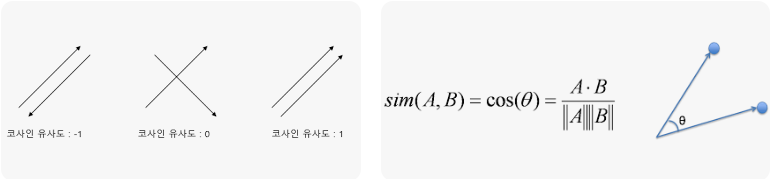

## cosine_Similarity

* 원리이해

In [46]:
A = [1, 2, 3]
B = [1, 4, 3]

abdot = (1*1) + (2*2) + (3*3)

av = np.sqrt((1**2 + 2**2 + 3**2))
bv = np.sqrt((1**2 + 2**2 + 3**2))

cos = abdot / (av * bv)
print(cos)

1.0


In [27]:
A = [1,2,3]
B = [4,5,6]

def cosine_similarity(A, B):
    A, B = np.array(A), np.array(B)
    return np.dot(A, B) / (np.linalg.norm(A) * np.linalg.norm(B))

print(cosine_similarity(A, B))  # 0.9746

0.9746318461970762


In [53]:
import numpy as np
def my_cosine_sim(A,B):
    abdot = np.dot(A,B)
    av = np.linalg.norm(A)
    bv = np.linalg.norm(B)
    return abdot /(av*bv)

In [42]:
from sklearn.metrics.pairwise import cosine_similarity
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

corpus_list = [
    '나는 고양이를 좋아한다',
    '나는 강아지를 좋아한다',
    '어제 비가 와서 날씨가 추웠다'
]

tk = Tokenizer() #텍스트를 숫자로 바꿔주는 도구
tk.fit_on_texts(corpus_list) #단어->숫자 인덱스 매핑 생성

vocab = tk.word_index #많이 나올수록 낮은 숫자
print(vocab)

seq_list = tk.texts_to_sequences(corpus_list) #문장이 단어 인덱스 리스트로 변환됨
print(seq_list)

pad_seq = pad_sequences(seq_list, maxlen=5, padding="post") #딥러닝 모델은 입력길이가 같아야함
print(pad_seq)


{'나는': 1, '좋아한다': 2, '고양이를': 3, '강아지를': 4, '어제': 5, '비가': 6, '와서': 7, '날씨가': 8, '추웠다': 9}
[[1, 3, 2], [1, 4, 2], [5, 6, 7, 8, 9]]
[[1 3 2 0 0]
 [1 4 2 0 0]
 [5 6 7 8 9]]


In [54]:
my_cosine_sim(pad_seq[0], pad_seq[1])

0.9914601339836675

In [39]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# 1. 데이터 (말뭉치)
corpus_list = [
    '나는 고양이를 좋아한다',
    '나는 강아지를 좋아한다',
    '어제 비가 와서 날씨가 추웠다'
]

# 2. 토크나이저(TfidfVectorizer)로 글자를 숫자로 바꾸기
tfidf_vt = TfidfVectorizer()
tfidf_matrix = tfidf_vt.fit_transform(corpus_list) # 여기서 '토큰화'와 '수치화'가 동시에 일어남

# 3. 사전(Vocabulary) 확인 - "컴퓨터가 단어를 어떻게 번호 매겼나?"
print("=== 생성된 사전 ===")
print(tfidf_vt.vocabulary_)

# 4. 코사인 유사도 계산 - "문장끼리 얼마나 비슷한가?"
# tfidf_matrix[0](고양이 문장)과 tfidf_matrix[1](강아지 문장) 비교
sim = cosine_similarity(tfidf_matrix[0], tfidf_matrix[1])

print(f"\n문장 1과 문장 2의 유사도: {sim[0][0]:.4f} ")

=== 생성된 사전 ===
{'나는': 2, '고양이를': 1, '좋아한다': 7, '강아지를': 0, '어제': 5, '비가': 4, '와서': 6, '날씨가': 3, '추웠다': 8}

문장 1과 문장 2의 유사도: 0.5363 
